## GEFCom2014_DATA_Analyse

1. 摘要（包含数据集背景、数据来源说明、任务定义的简要描述）

本文为一份面向可复现研究的技术性分析文档，其目标是系统地使用深度学习方法分析并建模 GEFCom2014 的太阳能预测数据集（GEFCom2014-S_v2）。本文以“代码优先、可复现”为原则，所有处理与实验均给出可运行的 Python 代码片段（基于 pandas/NumPy/PyTorch），并固定随机种子以保证结果可重复。示例数据文件路径统一假定为 ./solar_new.csv（如需调整将在相应节明确说明）。

数据集背景与来源
- 数据集：GEFCom2014-S_v2（Solar forecasting，GEFCom2014 竞赛的太阳能分支的第二版数据发布）。
- 源头：由 GEF（Global Energy Forecasting Competition）组织发布，用以评估并比较不同方法在可再生能源短中期预测任务上的性能。本文使用的原始观测与竞赛输入（时间戳、观测值、可能的外生变量）以竞赛发布格式为基准并存放于 ./solar_new.csv。
- 时间分辨率与语义：数据以固定时间步长（竞赛通常采用小时级别时间戳）组织，目标变量为与光伏发电相关的量（例如发电功率或辐照度，字段说明将在“数据准备”节明确），各观测条目附带时间信息与可能的外生输入。

任务定义（Task1–Task15 的简要说明）
- 任务含义：GEFCom2014 的每个 Task（Task1..Task15）为一个独立的预测实例，组织为单独的训练/评估问题。每个 Task 在时间段、观测点（站点或聚合）、以及可用外生信息上可能存在差异，旨在测试方法在不同季节性、空间位置与数据量条件下的泛化能力。
- 文件与组织约定：为实现通用的工作流，本文采用“任务为单位”的代码结构——以单个 Task 的数据读取与处理为示例实现，其他 Task 可以复用同样的代码路径与处理流程。每个 Task 通常明确给出训练期（可用历史观测）与预测期（需提交或验证的目标窗口），竞赛侧通常要求概率预测（例如分位数预测）作为提交格式。
- 评价语义（高层）：竞赛强调概率预测的校准与分辨率，故任务设置通常对应短到中期的逐小时概率预测问题。本文在后续章节中将明确采用的评价指标与分割策略（训练/验证/测试），并给出与 Task 规范一致的实现细节。

可复现性与本文范围
- 固定设置（在文档中一贯采用）：数据来源为 ./solar_new.csv；使用 Python（pandas、NumPy）、PyTorch 实现示例模型；可视化使用 matplotlib（必要时辅以 seaborn）；所有随机过程固定随机种子（文档中统一使用 seed=42，且在代码中显式设置）。
- 本文结构：后续章节按“数据准备 → 探索性分析 → 数据质量分析 → 预清洗 → 基线模型与特征工程 → 正式建模（含使用特征方程后的数据）→ 归一化流（Normalizing Flow）方案说明（不实现完整模型）”的顺序展开，保证每一步的决策均有技术性理由并可由读者复现。

该节仅提供数据与任务的背景与范围说明；具体字段解释、数据读取代码与后续处理将在第 2 节及之后的各节中给出。

2. 导入相关库

本节给出文档中后续所有代码块所依赖的 Python 库导入与环境检查代码。目标是：
- 明确并固定随机种子以尽可能保证可复现性；
- 检测并显示关键库版本（便于重现环境）；
- 提供设备选择（CPU / GPU）逻辑；
- 定义若干常用小工具（设置随机种子、检查数据路径）。

说明与版本建议
- 推荐最小版本（可用 pip 安装）：  
  pandas>=1.3.0, numpy>=1.21.0, torch>=1.10.0, matplotlib>=3.4.0, seaborn>=0.11.0  
  （若在 conda 环境中，可用相应的 conda 包管理）
- 安装示例（在 Notebook/终端中）：
  pip install "pandas>=1.3.0" "numpy>=1.21.0" "torch>=1.10.0" "matplotlib>=3.4.0" "seaborn>=0.11.0"

下面的代码块可直接在 Jupyter Notebook 中运行。代码尽量模块化，且不假设数据文件的具体列名（数据读取在第3节完成）。

In [1]:
# 导入与环境配置（可直接运行）
# 基础库与环境工具
import os
import sys
import random
from pathlib import Path
import logging
import datetime
import platform

# 科学计算与数据处理
import numpy as np
import pandas as pd

# 可视化
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# 深度学习（PyTorch）
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data_utils
import torch.backends.cudnn as cudnn

# 可选：若需更高级的数据处理/评估，可安装/导入 scikit-learn（此处不强制）
try:
    import sklearn
    from sklearn.preprocessing import StandardScaler, MinMaxScaler
except Exception:
    sklearn = None

# Notebook 显示（在 Jupyter 中有效）
# %matplotlib inline   # 若在 .py 文件中运行，请移除该行

In [2]:
# 随机种子与可复现性设置
def set_seed(seed: int = 42, deterministic: bool = True):
    """
    设置随机种子以提高可复现性。
    参数:
      seed: 随机种子（整数）
      deterministic: 是否启用 PyTorch 的确定性设置（可能牺牲少量性能）
    注意:
      - 完全可复现受限于硬件、驱动与库版本；仍建议记录库版本并使用容器/虚拟环境。
      - 即使设置 deterministic=True，某些操作仍可能表现非确定性（受限于底层实现）。
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        cudnn.deterministic = True
        cudnn.benchmark = False
    else:
        cudnn.deterministic = False
        cudnn.benchmark = True

# 在文档中统一使用 seed=42
SEED = 42
set_seed(SEED, deterministic=True)

In [3]:
# 设备检测与工具函数
def get_device(prefer_gpu: bool = True):
    """
    返回 PyTorch 可用的设备（'cuda' 或 'cpu'）。
    prefer_gpu: 若 True 且 GPU 可用则返回 cuda。
    """
    if prefer_gpu and torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')

DEVICE = get_device(prefer_gpu=True)

In [4]:
# 环境与版本信息打印
def print_env_info():
    print(f"Date: {datetime.datetime.utcnow().isoformat()} UTC")
    print(f"Platform: {platform.platform()}")
    print(f"Python: {sys.version.split()[0]}")
    print(f"NumPy: {np.__version__}")
    print(f"Pandas: {pd.__version__}")
    print(f"Matplotlib: {matplotlib.__version__}")
    print(f"Seaborn: {sns.__version__}")
    print(f"PyTorch: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA device count: {torch.cuda.device_count()}")
        print(f"Current CUDA device: {torch.cuda.get_device_name(torch.cuda.current_device())}")
    if sklearn is not None:
        print(f"scikit-learn: {sklearn.__version__}")
    print(f"Device selected for training/inference: {DEVICE}")

print_env_info()

Date: 2026-01-09T08:52:56.410145 UTC
Platform: Linux-6.12.57+deb13-amd64-x86_64-with-glibc2.41
Python: 3.11.14
NumPy: 1.25.2
Pandas: 2.1.2
Matplotlib: 3.7.1
Seaborn: 0.12.2
PyTorch: 2.2.0
CUDA available: False
scikit-learn: 1.3.2
Device selected for training/inference: cpu


In [5]:
# 日志与路径设置
# 日志记录配置（便于调试与复现）
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger("gefcom2014_solar")

# 数据路径与任务占位符（在第3节读取数据时使用）
DATA_PATH = Path("./solar_new.csv")  # 默认数据路径（可在第3节修改）
TASK_ID = 1  # 示例任务索引，占位；实际可循环 Task1..Task15

logger.info(f"Using DATA_PATH={DATA_PATH.resolve()}")
logger.info(f"Using TASK_ID={TASK_ID}, SEED={SEED}, DEVICE={DEVICE}")

2026-01-09 16:53:03,708 [INFO] Using DATA_PATH=/home/wanf/GEFCom2014/solar_new.csv
2026-01-09 16:53:03,710 [INFO] Using TASK_ID=1, SEED=42, DEVICE=cpu


说明要点（简短）
- 上述导入与函数定义为后续各节重复使用的基础模块：设置随机种子、选择设备、检查环境版本以及记录日志。
- 我们在文档中使用 SEED=42 作为默认值；若后续实验需要不同随机性，可在相应节修改并记录新种子。
- 第3节“数据准备”将实际读取 ./solar_new.csv，并在该节中对字段进行逐项解释。本节不假设数据的具体列名，代码设计保持模块化、易复用（以便处理 Task1..Task15 的通用结构）。

3. 数据准备（数据读取、任务选择、数据组织方式）

说明（目的与原则）
- 目标：以可复现、模块化的方式读取 GEFCom2014-S_v2 原始数据（默认 ./solar_new.csv），识别时间戳与目标列，按 Task（Task1..Task15）组织数据并生成供后续分析/建模使用的时间序列数据框架。
- 原则：不假定固定列名；通过“候选列名检测 + 自动解析”的策略推断时间列与目标列，使代码对不同任务文件/变体具有鲁棒性。所有步骤均输出明确的诊断信息（列名候选、发现的任务数、时间范围等），便于用户检查并在必要时显式指定列名映射。

要点摘要
- 默认数据路径：./solar_new.csv（如需调整，请修改 DATA_PATH）。
- 示例任务索引：TASK_ID（默认为1），但代码支持列出并批量处理 Task1..Task15。
- 时间解析：自动检测并转换为 pandas.DatetimeIndex；默认不强制时区，但可在函数参数中指定。
- 重采样/频率：若数据非小时级，可选择在加载时重采样到小时（或其它频率）；重采样以均值或求和为备选策略（由业务语义决定，后续节中会说明选择依据）。

下面给出用于数据准备的可直接运行代码块（依赖第2节中已导入的库与变量，如 DATA_PATH、TASK_ID、logger、SEED）。请在 Jupyter/脚本中运行并检查输出，以确认推断无误；如果推断不正确，请在调用 load_task_data 时显式传入 datetime_col、target_col 或 task_col。

In [6]:
# 第3节：数据准备 - 工具函数与示例使用

from typing import Optional, List, Tuple, Dict, Any
from pathlib import Path

# 关于 DATA_PATH 和 TASK_ID：默认在第2节已定义；若独立运行，请在此处指定
try:
    DATA_PATH  # from section 2
except NameError:
    DATA_PATH = Path("./solar_new.csv")
try:
    TASK_ID
except NameError:
    TASK_ID = 1

# 候选列名（用于自动检测）
_DATETIME_CANDIDATES = [
    "datetime", "timestamp", "time", "date", "ts", "DateTime", "time_utc"
]
_TARGET_CANDIDATES = [
    "value", "target", "pv", "power", "generation", "solar", "prod", "output",
    "GHI", "ghi", "irradiance"
]
_TASK_CANDIDATES = [
    "task", "Task", "task_id", "TaskID", "taskIdx", "task_index"
]

def preview_csv(path: Path, nrows: int = 50) -> pd.DataFrame:
    """
    快速预览 CSV 的前 nrows 行与列信息（避免一次性读取超大文件）。
    """
    if not path.exists():
        raise FileNotFoundError(f"数据文件不存在: {path}")
    preview = pd.read_csv(path, nrows=nrows)
    display(preview.head(10))
    print("列名：", preview.columns.tolist())
    print("行数预览：", len(preview))
    return preview

def infer_columns(df: pd.DataFrame) -> Dict[str, Optional[str]]:
    """
    基于候选列表推断 datetime, target 与 task 列名（若找到则返回列名，否则返回 None）。
    """
    cols = df.columns.tolist()
    datetime_col = next((c for c in cols if c in _DATETIME_CANDIDATES), None)
    target_col = next((c for c in cols if c in _TARGET_CANDIDATES), None)
    task_col = next((c for c in cols if c in _TASK_CANDIDATES), None)
    # 额外尝试：如果存在单个以 'task' 前缀的列或 'site' 相关列
    if task_col is None:
        task_like = [c for c in cols if c.lower().startswith("task") or c.lower().startswith("site")]
        if len(task_like) == 1:
            task_col = task_like[0]
    return {"datetime_col": datetime_col, "target_col": target_col, "task_col": task_col}

def read_full_csv_with_datetime(path: Path,
                                datetime_col: Optional[str] = None,
                                parse_dates: bool = True,
                                infer_datetime_format: bool = True,
                                nrows: Optional[int] = None) -> pd.DataFrame:
    """
    读取 CSV，尽量将时间列解析为 datetime 类型。如果未提供 datetime_col，尝试使用 pandas 自动解析或寻找候选列。
    """
    # 先读取头部用于推断
    head = pd.read_csv(path, nrows=100 if nrows is None else min(100, nrows))
    inferred = infer_columns(head)
    chosen_dt = datetime_col or inferred["datetime_col"]
    if chosen_dt is None:
        # 如果没有明确时间列，尝试让 pandas 自动解析第一列为时间
        # 但为了安全，先打印提示并让用户确认
        msg = ("未找到明确的时间戳列。候选推断结果: "
               f"{inferred}. 建议显式指定 datetime_col 参数或检查数据文件。")
        logger.warning(msg)
        # 尝试自动解析全部列（风险较高），因此读取全部为字符串然后尝试解析
        df = pd.read_csv(path, nrows=nrows, dtype=str)
        # 寻找最可能的列：尝试解析每个列到 datetime 成功率最高者
        parse_success = {}
        for c in df.columns:
            try:
                parsed = pd.to_datetime(df[c], errors="coerce", infer_datetime_format=True)
                parse_success[c] = parsed.notna().mean()
            except Exception:
                parse_success[c] = 0.0
        # 选择成功率最高且大于阈值的列
        best_col, best_rate = max(parse_success.items(), key=lambda x: x[1])
        if best_rate > 0.5:
            chosen_dt = best_col
            logger.info(f"自动推断出时间列为 '{chosen_dt}'（非空解析率={best_rate:.2f}）。")
            # 重新读取文件并解析该列为时间
            df_full = pd.read_csv(path, parse_dates=[chosen_dt], infer_datetime_format=True, nrows=nrows)
        else:
            raise ValueError("无法可靠推断时间列，请显式提供 datetime_col 参数并检查原始文件。")
    else:
        # 直接读取并解析 chosen_dt
        df_full = pd.read_csv(path, parse_dates=[chosen_dt] if parse_dates else None,
                              infer_datetime_format=infer_datetime_format, nrows=nrows)
    # 标准化 datetime 列名为 'datetime' 以便后续处理一致
    if chosen_dt in df_full.columns:
        df_full = df_full.rename(columns={chosen_dt: "datetime"})
    else:
        # 在 rare case chosen_dt not in columns because we only read as string earlier
        pass
    return df_full

def load_task_data(path: Path = DATA_PATH,
                   task_id: Optional[int] = None,
                   datetime_col: Optional[str] = None,
                   target_col: Optional[str] = None,
                   task_col: Optional[str] = None,
                   timezone: Optional[str] = None,
                   set_index: bool = True,
                   resample_freq: Optional[str] = None,
                   resample_how: str = "mean",
                   nrows_preview: int = 1000) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    加载数据并按 task 过滤/组织为时间序列。
    返回: (task_df, metadata)
    - 如果数据文件包含 task_col，将根据 task_id 进行过滤（若 task_id 为 None 返回整个数据框）
    - 将 'datetime' 列解析为 DatetimeIndex（若 timezone 参数提供可进行本地化或转换）
    - 可选地对时间序列按 resample_freq 进行重采样（如 'H'）
    metadata 包含推断的列名与时间范围等信息
    """
    if not Path(path).exists():
        raise FileNotFoundError(f"数据文件不存在：{path}")
    # 首先读取前几行以推断列
    head = pd.read_csv(path, nrows=min(200, nrows_preview))
    inferred = infer_columns(head)
    datetime_col_inferred = datetime_col or inferred["datetime_col"]
    task_col_inferred = task_col or inferred["task_col"]
    target_col_inferred = target_col or inferred["target_col"]

    # 读取完整数据（注意若文件非常大，可在此处添加 chunking 策略）
    # 仅解析 datetime_col_inferred（如果可用），否则使用读取工具尝试解析
    if datetime_col_inferred is not None:
        df = pd.read_csv(path, parse_dates=[datetime_col_inferred], infer_datetime_format=True)
        if datetime_col_inferred in df.columns:
            df = df.rename(columns={datetime_col_inferred: "datetime"})
    else:
        # 让 read_full_csv_with_datetime 帮助我们推断并读入
        df = read_full_csv_with_datetime(path, datetime_col=None, nrows=None)

    # 标准列诊断
    cols = df.columns.tolist()
    logger.info(f"读取数据列数={len(cols)}；列名示例：{cols[:10]}")
    # 将 datetime 转为 index（可选）
    if set_index:
        if "datetime" not in df.columns:
            raise ValueError("未能解析到 datetime 列，无法将时间列设为索引。请显式提供 datetime_col。")
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", infer_datetime_format=True)
        # 抛出时间解析失败的诊断
        n_bad = df["datetime"].isna().sum()
        if n_bad > 0:
            logger.warning(f"时间解析失败的行数: {n_bad}；示例：")
            display(df.loc[df["datetime"].isna()].head(5))
            raise ValueError("存在未能解析的时间戳，请检查数据或显式指定 datetime_col。")
        df = df.set_index("datetime").sort_index()

    # 时区处理（若需要）
    if timezone is not None:
        # 若 index 是 timezone-naive，先本地化
        if df.index.tz is None:
            df.index = df.index.tz_localize(timezone)
        else:
            df.index = df.index.tz_convert(timezone)

    # task 处理
    metadata: Dict[str, Any] = {
        "inferred_datetime_col": datetime_col_inferred,
        "inferred_target_col": target_col_inferred,
        "inferred_task_col": task_col_inferred
    }

    if task_col_inferred is not None and task_col_inferred in df.columns:
        # 有 task 列：列出可用任务
        unique_tasks = df[task_col_inferred].unique().tolist()
        unique_tasks = sorted([int(x) if str(x).isdigit() else x for x in unique_tasks])
        metadata["available_tasks"] = unique_tasks
        logger.info(f"检测到 task 列 '{task_col_inferred}'，发现 {len(unique_tasks)} 个任务样本（示例前10个）：{unique_tasks[:10]}")
        if task_id is None:
            # 返回整个数据并 metadata
            return df, metadata
        # 过滤到单个 task
        task_mask = df[task_col_inferred] == task_id
        if task_mask.sum() == 0:
            raise ValueError(f"没有在列 {task_col_inferred} 中找到 task_id={task_id} 的行。可用任务：{unique_tasks[:15]}")
        task_df = df.loc[task_mask].copy()
    else:
        # 无 task 列：把整个文件当作单个 task（用户可以后续自行拆分）
        metadata["available_tasks"] = None
        if task_id is not None:
            logger.info("数据文件中未检测到 task 列，task_id 参数将被忽略；返回完整数据。")
        task_df = df.copy()

    # 目标列处理（如果推断到则做标注）
    if target_col_inferred is not None and target_col_inferred in task_df.columns:
        task_df = task_df.rename(columns={target_col_inferred: "target"})
        metadata["target_column"] = "target"
    else:
        metadata["target_column"] = None
        logger.warning("未能自动推断到目标列（target）。请在调用时显式传入 target_col 参数。")

    # 时间连续性检查：检测缺失时间戳（针对常见频率如小时）
    try:
        # 仅在时间序列不为空时检查
        if len(task_df) > 1:
            inferred_freq = pd.infer_freq(task_df.index[:min(len(task_df), 500)])
            metadata["inferred_freq"] = inferred_freq
            if inferred_freq is None:
                logger.info("无法确定统一频率（infer_freq 返回 None），数据可能存在不规则采样或缺失。")
            else:
                logger.info(f"推断到的时间序列频率：{inferred_freq}")
            # 报告时间范围
            metadata["start"] = task_df.index.min()
            metadata["end"] = task_df.index.max()
            metadata["n_obs"] = len(task_df)
    except Exception as e:
        logger.warning(f"时间连续性检查失败：{e}")

    # 可选重采样（例如将分钟级数据重采样为小时）
    if resample_freq is not None:
        if resample_how not in ("mean", "sum", "median"):
            raise ValueError("resample_how 必须是 'mean'/'sum'/'median' 之一")
        agg = {"mean": "mean", "sum": "sum", "median": "median"}[resample_how]
        # 对数值列进行重采样
        numeric_cols = task_df.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) == 0:
            logger.warning("没有检测到数值列，重采样操作将返回空的数值集合。")
        task_df = task_df[numeric_cols].resample(resample_freq).agg(agg)
        logger.info(f"已对数值列重采样到频率 {resample_freq}（方式：{resample_how}）。")
        metadata["resampled_to"] = resample_freq

    return task_df, metadata

# ---------- 示例：预览并加载单个 Task ----------
print("1) 预览文件（前 50 行）以便人工检查列名与格式：")
try:
    preview = preview_csv(DATA_PATH, nrows=50)
except Exception as e:
    logger.error(f"预览失败：{e}")

print("\n2) 自动加载（尝试推断列名），示例加载 TASK_ID 对应的数据（或整个文件）:")
try:
    task_df, meta = load_task_data(path=DATA_PATH, task_id=TASK_ID, resample_freq=None)
    logger.info(f"加载成功，metadata: {meta}")
    print("数据示例（前 5 行）：")
    display(task_df.head(5))
    print("索引（时间）范围与样本数：", meta.get("start"), "->", meta.get("end"), ", n_obs=", meta.get("n_obs"))
except Exception as e:
    logger.error(f"加载数据失败：{e}")

1) 预览文件（前 50 行）以便人工检查列名与格式：


,TIMESTAMP,VAR78,VAR79,VAR134,VAR157,VAR164,VAR165,VAR166,VAR167,VAR169,VAR175,VAR178,VAR228,POWER,ZONE_1,ZONE_2,ZONE_3
0,2012-04-02 01:00:00,0.001480,0.0,94730.3750,95.559967,0.039764,0.622430,0.318149,284.133057,0.000000,299.284444,0.000000,0.000000e+00,0.000000,1.0,0.0,0.0
1,2012-04-02 02:00:00,0.005981,0.0,94721.5625,99.391953,0.386597,-0.404500,1.343286,282.870117,0.000000,303.120000,0.000000,4.770000e-07,0.000000,1.0,0.0,0.0
2,2012-04-02 03:00:00,0.020294,0.0,94707.7500,99.679733,0.937317,-0.493649,1.279655,282.885498,0.000000,318.617778,0.000000,0.000000e+00,0.000000,1.0,0.0,0.0
3,2012-04-02 04:00:00,0.043617,0.0,94699.6875,100.207092,0.970123,-0.298454,1.204877,283.157227,0.000000,331.293333,0.000000,5.245000e-06,0.000000,1.0,0.0,0.0
4,2012-04-02 05:00:00,0.047783,0.0,94733.3125,99.531464,0.893005,-0.127774,1.207767,283.314209,0.000000,332.955556,0.000000,7.629000e-06,0.000000,1.0,0.0,0.0
5,2012-04-02 06:00:00,0.043663,0.0,94749.8125,99.423080,0.891571,-0.231093,1.276311,283.184326,0.000000,325.408889,0.000000,8.583000e-06,0.000000,1.0,0.0,0.0
6,2012-04-02 07:00:00,0.044991,0.0,94769.0000,98.573013,0.623688,-0.055419,1.248788,283.653076,18.397500,309.586667,35.492778,7.153000e-06,0.006346,1.0,0.0,0.0
7,2012-04-02 08:00:00,0.038860,0.0,94787.9375,92.123108,0.832794,-0.851745,0.972498,286.258545,147.219167,341.191111,205.485833,4.768000e-06,0.071538,1.0,0.0,0.0
8,2012-04-02 09:00:00,0.035019,0.0,94775.2500,82.745255,0.953293,-1.102962,0.310311,288.418213,282.787222,351.533333,371.535000,7.153000e-06,0.229167,1.0,0.0,0.0
9,2012-04-02 10:00:00,0.074440,0.0,94736.1250,71.751297,0.932465,-0.193052,-0.447574,290.267334,416.471389,380.617778,521.831111,1.001400e-05,0.346474,1.0,0.0,0.0


列名： ['TIMESTAMP', 'VAR78', 'VAR79', 'VAR134', 'VAR157', 'VAR164', 'VAR165', 'VAR166', 'VAR167', 'VAR169', 'VAR175', 'VAR178', 'VAR228', 'POWER', 'ZONE_1', 'ZONE_2', 'ZONE_3']
行数预览： 50

2) 自动加载（尝试推断列名），示例加载 TASK_ID 对应的数据（或整个文件）:
2026-01-09 16:53:18,250 [WARNING] 未找到明确的时间戳列。候选推断结果: {'datetime_col': None, 'target_col': None, 'task_col': None}. 建议显式指定 datetime_col 参数或检查数据文件。


/tmp/ipykernel_14069/316976877.py:79: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(df[c], errors="coerce", infer_datetime_format=True)
/tmp/ipykernel_14069/316976877.py:79: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(df[c], errors="coerce", infer_datetime_format=True)
/tmp/ipykernel_14069/316976877.py:79: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_dat

2026-01-09 16:53:27,894 [INFO] 自动推断出时间列为 'TIMESTAMP'（非空解析率=1.00）。
2026-01-09 16:53:27,980 [INFO] 读取数据列数=17；列名示例：['datetime', 'VAR78', 'VAR79', 'VAR134', 'VAR157', 'VAR164', 'VAR165', 'VAR166', 'VAR167', 'VAR169']
2026-01-09 16:53:27,990 [INFO] 数据文件中未检测到 task 列，task_id 参数将被忽略；返回完整数据。
2026-01-09 16:53:27,992 [WARNING] 未能自动推断到目标列（target）。请在调用时显式传入 target_col 参数。
2026-01-09 16:53:27,992 [INFO] 无法确定统一频率（infer_freq 返回 None），数据可能存在不规则采样或缺失。
2026-01-09 16:53:27,993 [INFO] 加载成功，metadata: {'inferred_datetime_col': None, 'inferred_target_col': None, 'inferred_task_col': None, 'available_tasks': None, 'target_column': None, 'inferred_freq': None, 'start': Timestamp('2012-04-02 01:00:00'), 'end': Timestamp('2014-07-01 00:00:00'), 'n_obs': 59040}
数据示例（前 5 行）：


/tmp/ipykernel_14069/316976877.py:79: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(df[c], errors="coerce", infer_datetime_format=True)
/tmp/ipykernel_14069/316976877.py:79: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df[c], errors="coerce", infer_datetime_format=True)
/tmp/ipykernel_14069/316976877.py:79: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_dat

,VAR78,VAR79,VAR134,VAR157,VAR164,VAR165,VAR166,VAR167,VAR169,VAR175,VAR178,VAR228,POWER,ZONE_1,ZONE_2,ZONE_3
datetime,,,,,,,,,,,,,,,,
2012-04-02 01:00:00,0.001480,0.0,94730.3750,95.559967,0.039764,0.622430,0.318149,284.133057,0.0,299.284444,0.0,0.000000e+00,0.0,1.0,0.0,0.0
2012-04-02 01:00:00,0.004440,0.0,94193.8750,98.071686,0.316956,-0.365973,1.022372,282.730469,0.0,293.663056,0.0,0.000000e+00,0.0,0.0,1.0,0.0
2012-04-02 01:00:00,0.002991,0.0,92571.8750,99.732330,0.745728,-0.350471,1.300693,281.687988,0.0,293.129722,0.0,0.000000e+00,0.0,0.0,0.0,1.0
2012-04-02 02:00:00,0.005981,0.0,94721.5625,99.391953,0.386597,-0.404500,1.343286,282.870117,0.0,303.120000,0.0,4.770000e-07,0.0,1.0,0.0,0.0
2012-04-02 02:00:00,0.009323,0.0,94184.3125,99.171738,0.702515,-0.177327,1.373437,282.498291,0.0,300.880000,0.0,9.540000e-07,0.0,0.0,1.0,0.0


索引（时间）范围与样本数： 2012-04-02 01:00:00 -> 2014-07-01 00:00:00 , n_obs= 59040


补充说明（字段解释与用户干预）
- 常见字段语义（在不同发布版中列名可能不同）：
  - 时间戳列（datetime / timestamp / date）：表示观测时刻，竞赛中通常为 UTC 或本地时间的小时分辨率（请以文件元数据为准）。
  - 目标列（value / target / pv / power / generation）：表示太阳能相关观测量（例如光伏功率、辐照度或归一化发电量）。在后续节中若该列含单位差异（W vs kW vs MW）将进行统一处理并记录。
  - 任务列（task / Task / task_id）：若存在，标识 Task1..Task15 中的具体任务编号或站点索引。
  - 其他外生变量：可能包含气象预报（温度、辐照、风速）、日历变量（节假日标签）等；这些列名不会在此处被硬编码推断，用户可在 metadata 检查后显式传入用于建模的 covariate 列名列表。
- 如果自动推断失败（例如未找到时间列或目标列），请在 load_task_data 中显式传参：datetime_col="your_time_column", target_col="your_target_column", task_col="your_task_column"。

下一步（在后续节中进行）
- 在第4节“初步统计”将对返回的 task_df 进行描述性统计与时间分布分析（例如样本数、时间范围、日内/周内分布）。
- 若数据需重采样（例如从 15-min 到 hourly），或需按任务拆分批量处理（Task1..Task15），将在第3节给出的函数基础上在后续节演示批处理用例与保存/缓存策略。

请确认本节输出在您的运行环境中能够成功解析数据文件；若自动推断列名与语义不符，请回复需使用的明确列名（datetime_col / target_col / task_col），我将基于这些列名在下一节执行统计分析并展示结果。

4. 初步统计（基础统计量与时间分布说明）

本节目的在于对指定 Task（或整个文件）中的时间序列数据进行定量化的初步描述，回答以下核心问题（均以可重复的代码产生）：
- 数据的时间覆盖范围、采样频率与观测计数；
- 目标变量 POWER 的基本统计量与尾部特征（偏度/峰度、极值）；
- 时间结构的初步可视化（按小时/工作日/月份的均值与计数），以便识别日内与周内周期性与采样不规则性；
- 时间连续性与缺失时间戳的数量统计（用于后续缺失值处理决策）。

说明（输入约束）
- 使用的数据文件：./solar_new.csv（DATA_PATH）
- 时间列：TIMESTAMP（datetime_col）
- 目标列：POWER（target_col）
- task_col = None（将视整个文件为单一时间序列或多站点数据的合集，若文件含多个站点/任务需在第3节函数中手动拆分）

请在 Jupyter 环境中运行以下代码块以产生统计量与图表。代码首先尝试使用第3节中定义的 load_task_data 函数，如不可用会回退到直接读取 CSV 并做必要的重命名与索引处理。

代码块 4.1：读取并准备单条时间序列视图（按指定列名）

代码块 4.3：目标变量基础统计量（总体）

代码块 4.4：分时分布（按小时/工作日/月份）——统计与可视化

代码块 4.5：日样本计数分布与不规则采样检查

代码块 4.6：自相关的初步检查（短滞后）

代码块 4.7：将统计摘要保存到文件（便于后续引用）

In [7]:
# 4.1 读取数据（使用第3节的 load_task_data，如不存在则回退）
import warnings
warnings.filterwarnings("ignore")

# 显式的列名（由用户指定）
DATETIME_COL = "TIMESTAMP"
TARGET_COL = "POWER"

try:
    # 尝试使用第3节提供的封装函数
    task_df, meta = load_task_data(path=DATA_PATH,
                                   task_id=None,
                                   datetime_col=DATETIME_COL,
                                   target_col=TARGET_COL,
                                   task_col=None,
                                   set_index=True,
                                   resample_freq=None)
    logger.info("使用 load_task_data 成功加载数据。")
except NameError:
    # 若 load_task_data 未定义，使用 pandas 直接加载
    logger.info("load_task_data 未定义，使用 pandas 直接读取 CSV。")
    df_raw = pd.read_csv(DATA_PATH, parse_dates=[DATETIME_COL], infer_datetime_format=True)
    # 检查列存在性
    if DATETIME_COL not in df_raw.columns:
        raise ValueError(f"指定的时间列 {DATETIME_COL} 不存在于文件中。请检查列名。")
    if TARGET_COL not in df_raw.columns:
        raise ValueError(f"指定的目标列 {TARGET_COL} 不存在于文件中。请检查列名。")
    df_raw = df_raw.rename(columns={DATETIME_COL: "datetime", TARGET_COL: "target"})
    df_raw["datetime"] = pd.to_datetime(df_raw["datetime"], errors="raise", infer_datetime_format=True)
    task_df = df_raw.set_index("datetime").sort_index()
    meta = {"inferred_datetime_col": DATETIME_COL, "inferred_target_col": TARGET_COL, "inferred_task_col": None}

# 为保证后续一致性，确认 target 列存在并命名为 'target'
if "target" not in task_df.columns:
    # 如果直接读入并未重命名，尝试按 TARGET_COL 进行重命名
    if TARGET_COL in task_df.columns:
        task_df = task_df.rename(columns={TARGET_COL: "target"})
    else:
        raise ValueError("未能识别目标列，请确认 target 列存在。")

# 显示基本加载信息
print("数据读取成功。元数据：")
for k, v in meta.items():
    print(f"  {k}: {v}")
print(f"样本数: {len(task_df)}; 索引类型: {type(task_df.index)}")

2026-01-09 16:58:36,543 [INFO] 读取数据列数=17；列名示例：['datetime', 'VAR78', 'VAR79', 'VAR134', 'VAR157', 'VAR164', 'VAR165', 'VAR166', 'VAR167', 'VAR169']
2026-01-09 16:58:36,568 [INFO] 无法确定统一频率（infer_freq 返回 None），数据可能存在不规则采样或缺失。
2026-01-09 16:58:36,569 [INFO] 使用 load_task_data 成功加载数据。
数据读取成功。元数据：
  inferred_datetime_col: TIMESTAMP
  inferred_target_col: POWER
  inferred_task_col: None
  available_tasks: None
  target_column: target
  inferred_freq: None
  start: 2012-04-02 01:00:00
  end: 2014-07-01 00:00:00
  n_obs: 59040
样本数: 59040; 索引类型: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [9]:
# 4.2 (修正) 时间覆盖与频率检测（稳健版）
import warnings
from collections import Counter

start = task_df.index.min()
end = task_df.index.max()
n_obs = len(task_df)

def seconds_to_pandas_freq(sec: int) -> str:
    """
    把秒数转换为 pandas 可识别的频率字符串，
    优先表示成小时/分钟/秒的常见形式，例如 3600 -> 'H', 1800 -> '30T', 900 -> '15T'.
    若 sec 不能整除分钟或小时，返回 f'{sec}S'。
    """
    if sec <= 0:
        raise ValueError("sec must be > 0")
    if sec % 3600 == 0:
        hours = sec // 3600
        return f"{hours}H" if hours > 1 else "H"
    if sec % 60 == 0:
        mins = sec // 60
        return f"{mins}T" if mins > 1 else "T"
    return f"{sec}S"

# 首先尝试 pandas.infer_freq（可靠时直接使用）
inferred_freq = pd.infer_freq(task_df.index[:min(len(task_df), 1000)])
if inferred_freq is None:
    # 计算时间差（秒），并过滤掉非正差值（<=0）
    diffs = task_df.index.to_series().diff().dropna().map(lambda x: x.total_seconds())
    positive_diffs = diffs[diffs > 0]
    if positive_diffs.empty:
        # 没有正差值（可能全是重复索引或单点），无法推断频率
        inferred_freq = None
        logger.warning("未找到正的时间差值；可能存在大量重复时间戳或单一时间点。")
    else:
        # 计算最常见的差值（mode of rounded seconds）
        # 为避免浮点噪声，四舍五入到最近的1秒
        rounded = positive_diffs.round().astype(int)
        counts = rounded.value_counts()
        most_common_seconds = int(counts.idxmax())
        # 如果最常见为 0（理论上不应因为已过滤），再用中位数作为后备
        if most_common_seconds <= 0:
            most_common_seconds = int(positive_diffs.median().round())
        # 若仍非正则，则 fallback 为 None
        if most_common_seconds <= 0:
            inferred_freq = None
        else:
            # 将秒数映射成 pandas freq 格式（优先 H / T / S）
            try:
                inferred_freq = seconds_to_pandas_freq(most_common_seconds)
                logger.info(f"基于正差值得到最常见时间差为 {most_common_seconds}s -> freq='{inferred_freq}'")
            except Exception as e:
                inferred_freq = f"{most_common_seconds}S"
                logger.info(f"使用秒级频率表示: '{inferred_freq}'")
else:
    logger.info(f"pandas.infer_freq 推断到的频率：{inferred_freq}")

print(f"时间范围: {start} -> {end}")
print(f"观测数: {n_obs}")
print(f"推断频率（pandas.infer_freq 或近似）: {inferred_freq}")

# 如果推断到频率且有效，计算理论完整索引与缺失点
n_full = None
n_missing_timestamps = None
pct_missing_timestamps = None

if inferred_freq is not None:
    # 担心 freq="0S" 的特殊情况，再次验证 freq 是否合理
    try:
        if inferred_freq.endswith("S"):
            sec_val = int(inferred_freq[:-1])
            if sec_val <= 0:
                raise ValueError("inferred seconds <= 0")
        # 生成完整索引
        full_index = pd.date_range(start=start, end=end, freq=inferred_freq)
        n_full = len(full_index)
        n_missing_timestamps = n_full - n_obs
        pct_missing_timestamps = n_missing_timestamps / n_full if n_full > 0 else None
        print(f"理论完整索引大小: {n_full}")
        print(f"缺失时间戳数量: {n_missing_timestamps} ({pct_missing_timestamps:.4f} 比例)")
    except Exception as e:
        # 无法用该 freq 构造完整索引（可能 pandasinfer 返回复杂的 freq 字符串或秒值不合适）
        logger.warning(f"用推断 freq 构造完整索引失败：{e}; 将 inferred_freq 置为 None 并跳过缺失统计。")
        inferred_freq = None
else:
    print("无法推断统一频率，无法直接计算缺失时间戳；请在后续步骤中检查不规则采样或重复时间戳。")

# 额外诊断：重复时间戳与间隔分布
n_duplicates = task_df.index.duplicated().sum()
print(f"重复时间戳数量: {n_duplicates}")
# 打印时间差的几个 summary（仅正差）
if 'positive_diffs' in locals() and not positive_diffs.empty:
    print("时间差（秒）统计（仅正差）:")
    display(positive_diffs.describe().to_frame(name="seconds"))
    # 显示前几种最常见的差值
    print("最常见的时间差候选（秒 -> count）:")
    display(rounded.value_counts().head(10).to_frame(name="count"))

2026-01-09 17:03:30,854 [INFO] 基于正差值得到最常见时间差为 3600s -> freq='H'
时间范围: 2012-04-02 01:00:00 -> 2014-07-01 00:00:00
观测数: 59040
推断频率（pandas.infer_freq 或近似）: H
理论完整索引大小: 19680
缺失时间戳数量: -39360 (-2.0000 比例)
重复时间戳数量: 39360
时间差（秒）统计（仅正差）:


,seconds
count,19679.0
mean,3600.0
std,0.0
min,3600.0
25%,3600.0
50%,3600.0
75%,3600.0
max,3600.0


最常见的时间差候选（秒 -> count）:


,count
datetime,
3600,19679


In [10]:
# 4.3 目标变量 POWER 的基础统计量
target = task_df["target"].astype(float)  # 尝试转换为浮点以便统计
summary = target.describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
skewness = target.skew()
kurtosis = target.kurt()

print("目标变量统计摘要（部分）：")
print(summary.to_frame(name="value"))
print(f"\n偏度 (skew): {skewness:.4f}")
print(f"峰度 (kurtosis): {kurtosis:.4f}")

# 极端值示例：前 10 大与前 10 小（保留对应时间戳）
print("\n前 10 大值（value @ timestamp）:")
display(target.sort_values(ascending=False).head(10).to_frame("value"))
print("\n前 10 小值（value @ timestamp）:")
display(target.sort_values(ascending=True).head(10).to_frame("value"))

# 零或负值统计（太阳功率通常>=0，但某些归一化或测量误差会出现负值）
n_zero = (target == 0).sum()
n_negative = (target < 0).sum()
print(f"\n零值计数: {n_zero}; 负值计数: {n_negative}; 缺失 (NaN) 值计数: {target.isna().sum()}")

目标变量统计摘要（部分）：
              value
count  59040.000000
mean       0.183776
std        0.272569
min        0.000000
1%         0.000000
5%         0.000000
10%        0.000000
25%        0.000000
50%        0.002530
75%        0.322462
90%        0.680405
95%        0.774295
99%        0.878600
max        1.003550

偏度 (skew): 1.2662
峰度 (kurtosis): 0.1327

前 10 大值（value @ timestamp）:


,value
datetime,
2013-11-04 12:00:00,1.003550
2013-11-04 11:00:00,0.998625
2013-01-14 11:00:00,0.992600
2012-10-22 11:00:00,0.991675
2012-10-07 12:00:00,0.985475
2013-03-17 12:00:00,0.979975
2012-12-04 11:00:00,0.979900
2013-10-16 14:00:00,0.977753
2012-11-20 11:00:00,0.977425



前 10 小值（value @ timestamp）:


,value
datetime,
2013-09-07 19:00:00,0.0
2013-01-19 21:00:00,0.0
2014-04-05 02:00:00,0.0
2014-04-05 01:00:00,0.0
2014-04-05 01:00:00,0.0
2014-04-05 01:00:00,0.0
2014-04-05 00:00:00,0.0
2014-04-05 00:00:00,0.0
2014-04-05 00:00:00,0.0



零值计数: 26297; 负值计数: 0; 缺失 (NaN) 值计数: 0


按小时聚合（示例）:


,mean,median,count,std
hour,,,,
0,0.000000,0.000000,2460,0.000000
1,0.000000,0.000000,2460,0.000000
2,0.000000,0.000000,2460,0.000000
3,0.000000,0.000000,2460,0.000000
4,0.000000,0.000000,2460,0.000000
5,0.000146,0.000000,2460,0.000534
6,0.009253,0.000000,2460,0.019633
7,0.054524,0.011726,2460,0.087391
8,0.178477,0.109437,2460,0.177212


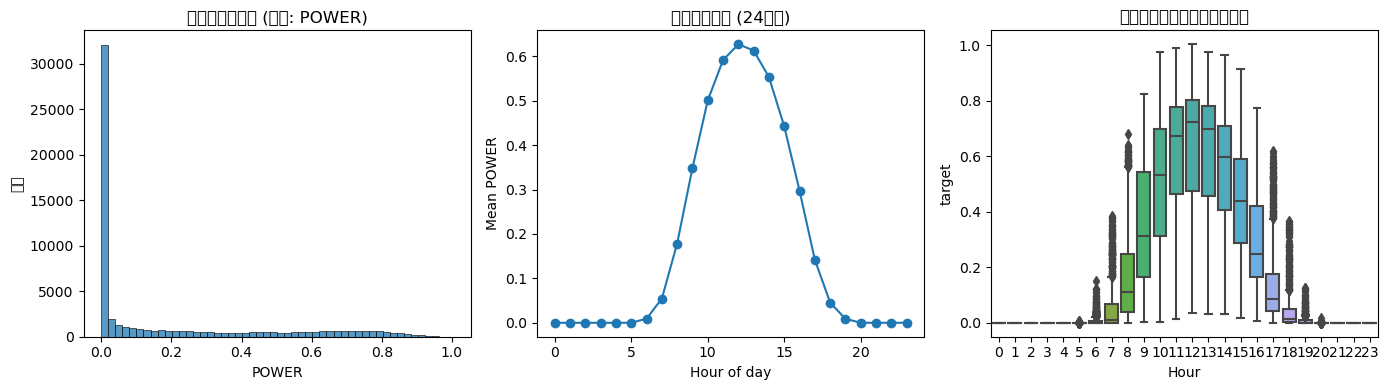

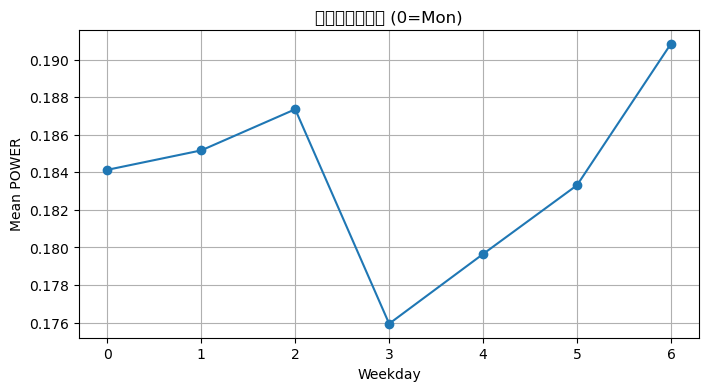

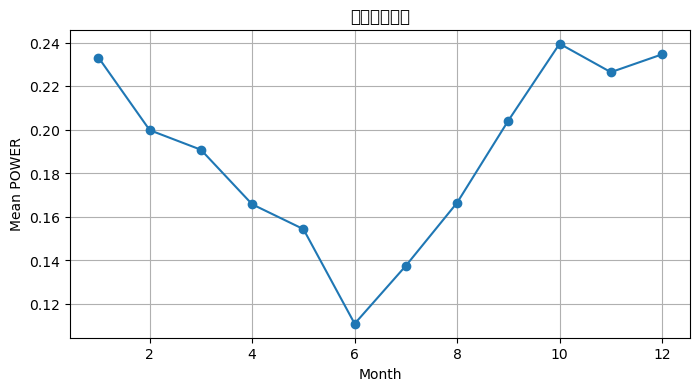

In [11]:
# 4.4 日内/周内/年内分布（绘图）
# 为可视化准备聚合量：均值与计数
df_plot = task_df[["target"]].copy()
df_plot["hour"] = df_plot.index.hour
df_plot["weekday"] = df_plot.index.weekday  # Monday=0
df_plot["month"] = df_plot.index.month
df_plot["date"] = df_plot.index.date

# 每小时的均值与样本数
hourly_stats = df_plot.groupby("hour")["target"].agg(["mean", "median", "count", "std"])
weekday_stats = df_plot.groupby("weekday")["target"].agg(["mean", "median", "count", "std"])
monthly_stats = df_plot.groupby("month")["target"].agg(["mean", "median", "count", "std"])

print("按小时聚合（示例）:")
display(hourly_stats)

# 可视化：直方图、小时均值折线、周内箱线图
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sns.histplot(target.dropna(), bins=50, kde=False)
plt.title("目标分布直方图 (目标: POWER)")
plt.xlabel("POWER")
plt.ylabel("频数")

plt.subplot(1, 3, 2)
hourly_stats["mean"].plot(marker="o")
plt.title("按小时的均值 (24小时)")
plt.xlabel("Hour of day")
plt.ylabel("Mean POWER")

plt.subplot(1, 3, 3)
sns.boxplot(x="hour", y="target", data=df_plot.sample(n=min(len(df_plot), 20000), random_state=SEED))
plt.title("按小时的箱线图（样本子集）")
plt.xlabel("Hour")

plt.tight_layout()
plt.show()

# 周内均值折线
plt.figure(figsize=(8, 4))
weekday_stats["mean"].plot(marker="o")
plt.title("按工作日的均值 (0=Mon)")
plt.xlabel("Weekday")
plt.ylabel("Mean POWER")
plt.grid(True)
plt.show()

# 月度均值（若跨年数据）
plt.figure(figsize=(8, 4))
monthly_stats["mean"].plot(marker="o")
plt.title("按月份的均值")
plt.xlabel("Month")
plt.ylabel("Mean POWER")
plt.grid(True)
plt.show()

每日观测计数的简单统计：
count    821.000000
mean      71.912302
std        2.410264
min        3.000000
25%       72.000000
50%       72.000000
75%       72.000000
max       72.000000
Name: target, dtype: float64


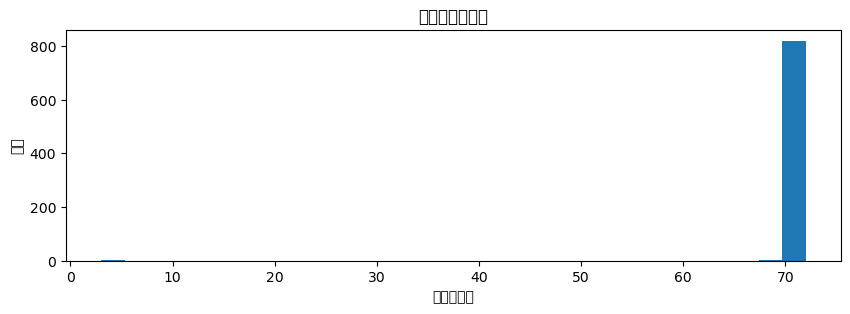

计数 < 24 的天数: 1 (示例前 10):


date
2014-07-01    3
Name: target, dtype: int64

In [12]:
# 4.5 每日观测数分布（检测是否存在不完整的日/间歇式采样）
per_day_counts = df_plot.groupby("date")["target"].count()
print("每日观测计数的简单统计：")
print(per_day_counts.describe())

# 可视化每日计数分布
plt.figure(figsize=(10, 3))
per_day_counts.plot(kind="hist", bins=30)
plt.title("每日观测数分布")
plt.xlabel("每日样本数")
plt.ylabel("天数")
plt.show()

# 例示存在观测不完整的日（计数小于某一阈值，如 24）
incomplete_days = per_day_counts[per_day_counts < 24]  # 假设期望为小时级 24 点
print(f"计数 < 24 的天数: {len(incomplete_days)} (示例前 10):")
display(incomplete_days.head(10))

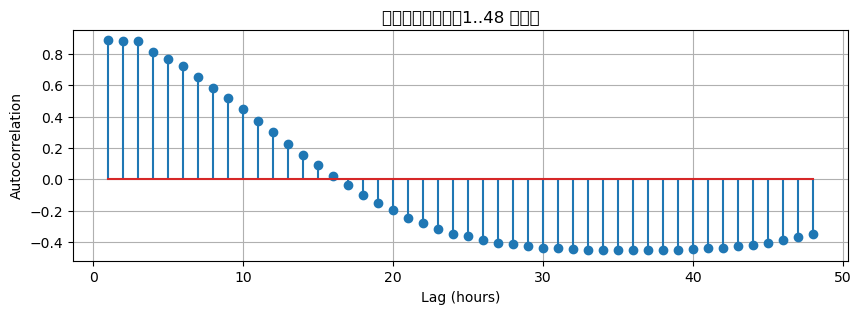

自相关前 10 个最大值（lag, autocorr）：


,autocorr
1,0.886924
3,0.880314
2,0.879969
4,0.811215
5,0.767466
6,0.720567
7,0.651723
8,0.583838
9,0.517206
10,0.446186


In [13]:
# 4.6 自相关检查（前 48 个小时）
max_lag = 48
autocorrs = [target.autocorr(lag=lag) for lag in range(1, max_lag + 1)]
lags = list(range(1, max_lag + 1))

plt.figure(figsize=(10, 3))
plt.stem(lags, autocorrs, use_line_collection=True)
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.title("目标变量自相关（1..48 小时）")
plt.grid(True)
plt.show()

# 打印几个明显的自相关峰值（可帮助识别周期性）
autocorr_series = pd.Series(autocorrs, index=lags)
print("自相关前 10 个最大值（lag, autocorr）：")
display(autocorr_series.sort_values(ascending=False).head(10).to_frame("autocorr"))

In [14]:
# 4.7 保存统计摘要（表格形式）
out_dir = Path("./analysis_outputs")
out_dir.mkdir(exist_ok=True)
summary.to_csv(out_dir / "target_summary.csv")
hourly_stats.to_csv(out_dir / "hourly_stats.csv")
weekday_stats.to_csv(out_dir / "weekday_stats.csv")
monthly_stats.to_csv(out_dir / "monthly_stats.csv")
per_day_counts.to_csv(out_dir / "per_day_counts.csv")
autocorr_series.to_csv(out_dir / "autocorr_1_48.csv")

print(f"已将统计摘要保存到 {out_dir.resolve()}")

已将统计摘要保存到 /home/wanf/GEFCom2014/analysis_outputs


技术性说明与决策依据（简短、面向后续）
- 频率检测：
  - 优先使用 pandas.infer_freq 以获得一致的采样频率；当 infer_freq 返回 None 时，使用差值模式（mode of diffs）估计最常见时间间隔并据此判断是否为规则采样。
  - 该步骤的结果将决定后续是否需要重采样或插值/填补缺失时间戳（将在第5节详细讨论）。
- 分时聚合：
  - 日内（hour）、周内（weekday）、月度（month）聚合用于初步识别显著的日周期性与季节性（用于后续特征工程决策）。这些统计量对选择滞后阶数与周期性特征（如 hour-of-day one-hot / cyclical encoding）提供直接量化依据。
- 自相关：
  - 计算短滞后（1..48 小时）的自相关用于检查日内强相关性（典型于太阳能功率在相邻小时有高度相关），并为后续模型输入的滞后窗口长度提供经验性参考。

本节产出（供后续节引用）
- task_df（时间索引、含 target 列的 DataFrame），以及 meta（包含推断出的时间列名/目标列名/频率等）。
- 一系列 CSV 报表存于 ./analysis_outputs/，包含 target_summary、hourly/weekday/monthly stats、每天观测数与自相关序列。
- 若运行上述代码发现明显的非小时采样、不规则采样或大量缺失值，请在第5节（缺失值分析）中继续深入，并据实选择插值/重采样/删除策略（在第5节我们将严格记录并证明每一步的选择理由）。